# 06 — Interpretation, Calibration & Final Model 
SpiriCom · Huawei Technologies Tunisia · PFE 2026

In [1]:
import pandas as pd
import numpy as np
import json, joblib
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score,
                             brier_score_loss, precision_recall_curve)
import xgboost as xgb

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('WARNING: shap not installed - pip install shap')

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', muted='#6B7280')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'figure.dpi': 120, 'savefig.dpi': 300,
                     'savefig.bbox': 'tight'})

PROC_DIR, MODEL_DIR, OUT_DIR = Path('data/processed'), Path('models'), Path('data/outputs')
FIG_DIR = OUT_DIR / 'figures'

# NB06-3: utf-8, handle-safe JSON helpers
def jdump(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, indent=2, default=str)
def jload(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

df   = pd.read_parquet(PROC_DIR / 'churn_features_v6.parquet')
meta = jload(MODEL_DIR / 'churn_features_meta.json')
FEATURES = [c for c in meta['feature_columns']
            if c in df.columns and df[c].nunique() > 1]
print(f'{len(df):,} rows, {len(FEATURES)} usable features')


2,566 rows, 56 usable features


## 1 — `user_class` leak audit & blocklist update (NB06-1)

In [2]:
# ── Leakage audit: user_class feature family (NB06-1) ───────────────────
# This step validates whether derived segmentation features introduce
# indirect label leakage into the modeling pipeline.

# user_class_* features represent high-level behavioral segmentation
# typically derived from traffic composition (e.g., heavy streaming,
# gaming, enterprise usage). These segments may implicitly encode
# volume-based signals that were previously blocked.

uc_cols = [c for c in FEATURES if c.startswith('user_class_')]

print('user_class one-hot columns:', uc_cols)

# ── Disengagement rate analysis per segment ────────────────────────────
# We compute conditional churn probability per category to detect
# whether segmentation is predictive due to genuine behavior or
# due to leakage from volume-derived features.

print('\nDisengagement rate per user_class group:')

y_all = df['churn'].astype(int)

for c in uc_cols:
    m = (df[c] == 1).values
    if m.sum() > 0:
        print(f'  {c:<34s} {y_all[m].mean()*100:>5.1f}%  (n={int(m.sum()):,})')

# ── Statistical interpretation ─────────────────────────────────────────
# If churn rates are systematically separated across these categories,
# it indicates that user_class is not an independent behavioral feature
# but a compressed representation of usage volume patterns.

print('\nVERDICT: categories are traffic-mix labels (derived from the blocked')
print('volume family) -> user_class joins the leakage blocklist.')

# ── Blocklist update (governance enforcement layer) ────────────────────
# To ensure strict feature hygiene, we explicitly extend the leakage
# blocklist to prevent downstream model contamination.

bl = jload(MODEL_DIR / 'leakage_blocklist.json')

added = sorted(set(['user_class'] + uc_cols) - set(bl['blocked_features']))

bl['blocked_features'] = sorted(set(bl['blocked_features'] +
                                    ['user_class'] + uc_cols))

# Remove from allowed interpretability examples
bl['allowed_examples'] = [c for c in bl.get('allowed_examples', [])
                          if c != 'user_class']

bl['amended_at'] = datetime.now().isoformat()
bl['amendment']  = 'NB06-1: user_class = dominant-traffic-mix class, label leak'

jdump(bl, MODEL_DIR / 'leakage_blocklist.json')

print(f'\nBlocklist amended (+{len(added)}): {added}')

# ── Feature set reconstruction (leakage-safe modeling space) ───────────
# Removing user_class ensures that only *exogenous or structural* features
# remain in the modeling pipeline, avoiding post-hoc encoding of target signal.

FEATURES_V2 = [c for c in FEATURES if not c.startswith('user_class_')]

tr = df[df['split'] == 'train']
te = df[df['split'] == 'test']

X_tr, y_tr = tr[FEATURES_V2], tr['churn'].astype(int)
X_te, y_te = te[FEATURES_V2], te['churn'].astype(int)

# ── Prevalence estimation ──────────────────────────────────────────────
# This defines the baseline class imbalance level used for:
#   - PR-AUC normalization
#   - scale_pos_weight calibration (if applicable)
#   - lift interpretation in evaluation

prevalence = float(y_tr.mean())

print(f'Clean feature set: {len(FEATURES_V2)} features')

user_class one-hot columns: ['user_class_GAME_TRAFFIC', 'user_class_IM_TRAFFIC', 'user_class_OTHER_TRAFFIC', 'user_class_SNS_TRAFFIC', 'user_class_STREAMING_TRAFFIC', 'user_class_VOIP_TRAFFIC', 'user_class_WEB_BROWSING_TRAFFIC']

Disengagement rate per user_class group:
  user_class_GAME_TRAFFIC             33.3%  (n=3)
  user_class_IM_TRAFFIC               50.0%  (n=8)
  user_class_OTHER_TRAFFIC            91.3%  (n=495)
  user_class_SNS_TRAFFIC              43.1%  (n=116)
  user_class_STREAMING_TRAFFIC        14.7%  (n=1,347)
  user_class_VOIP_TRAFFIC              7.7%  (n=26)
  user_class_WEB_BROWSING_TRAFFIC     28.2%  (n=571)

VERDICT: categories are traffic-mix labels (derived from the blocked
volume family) -> user_class joins the leakage blocklist.

Blocklist amended (+0): []
Clean feature set: 49 features


## 2 — Re-selection on the clean set (final report numbers)

In [3]:
# ── Re-selection of models on leakage-clean feature space (NB06-2) ─────
# This stage re-trains and re-evaluates all candidate models after removal
# of leakage-inducing features (notably user_class_*).
#
# The objective is to produce final, publication-grade performance metrics
# that reflect only genuinely available predictive signals.

neg, pos = int((y_tr == 0).sum()), int((y_tr == 1).sum())

# ── Cross-validation design ────────────────────────────────────────────
# Stratified K-Fold ensures class distribution consistency across folds,
# preserving the rare-event structure of disengagement labels.

cv = StratifiedKFold(5, shuffle=True, random_state=42)

# ── Model definitions ───────────────────────────────────────────────────
# All models are kept identical to NB05 to ensure comparability.
# Only the feature space has changed (leakage removal effect isolation).

MODELS = {
    'logistic_regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('lr',  LogisticRegression(max_iter=3000,
                                   class_weight='balanced',
                                   random_state=42))
    ]),

    'random_forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('rf',  RandomForestClassifier(n_estimators=400,
                                       min_samples_leaf=3,
                                       class_weight='balanced',
                                       random_state=42,
                                       n_jobs=-1))
    ]),

    'xgboost': xgb.XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.8,
        scale_pos_weight=neg / pos,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
}

# ── Threshold optimization function ────────────────────────────────────
# We optimize decision threshold using F1-score on OOF predictions.
# This ensures optimal balance between precision and recall under
# class imbalance without touching the test set.

def tune_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    if len(thr) == 0:
        return 0.5

    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-9)
    return float(thr[int(np.nanargmax(f1))])

# ── Out-of-fold evaluation + final test evaluation ─────────────────────
# This loop performs:
#   1. OOF prediction → unbiased generalization estimate
#   2. Threshold calibration → deployment-ready decision boundary
#   3. Final test evaluation → true hold-out performance

oof, fitted, results = {}, {}, {}

for name, model in MODELS.items():

    # OOF predictions simulate unseen population behavior
    proba_oof = cross_val_predict(
        model, X_tr, y_tr,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    # Threshold calibration based only on training folds
    thr = tune_threshold(y_tr, proba_oof)

    # Store OOF metrics (robust model selection criterion)
    oof[name] = dict(
        pr_auc=average_precision_score(y_tr, proba_oof),
        roc_auc=roc_auc_score(y_tr, proba_oof),
        threshold=thr
    )

    # Final model fitting on full training set
    model.fit(X_tr, y_tr)
    fitted[name] = model

    # Test evaluation (strict hold-out validation)
    p = model.predict_proba(X_te)[:, 1]
    pred = (p >= thr).astype(int)

    results[name] = dict(
        roc_auc=roc_auc_score(y_te, p),
        pr_auc=average_precision_score(y_te, p),
        lift=average_precision_score(y_te, p) / float(y_te.mean()),
        f1=f1_score(y_te, pred),
        precision=precision_score(y_te, pred),
        recall=recall_score(y_te, pred),
        brier=brier_score_loss(y_te, p),
        threshold=thr,
        _proba=p
    )

    # Model reporting: OOF vs Test stability check
    print(f'{name:<22s} OOF PR-AUC {oof[name]["pr_auc"]:.4f} | '
          f'TEST PR-AUC {results[name]["pr_auc"]:.4f} '
          f'ROC {results[name]["roc_auc"]:.4f} '
          f'F1 {results[name]["f1"]:.4f} '
          f'Brier {results[name]["brier"]:.4f}')

# ── Model selection criterion ───────────────────────────────────────────
# Final model is selected using OOF PR-AUC, not test performance,
# to avoid any implicit test-set overfitting.

best_name = max(oof, key=lambda k: oof[k]['pr_auc'])

print(f'\nSelected on clean OOF PR-AUC: {best_name}')
print('(these post-user_class numbers replace the NB05 table in the report)')

logistic_regression    OOF PR-AUC 0.8000 | TEST PR-AUC 0.8029 ROC 0.8150 F1 0.7070 Brier 0.1423
random_forest          OOF PR-AUC 0.8338 | TEST PR-AUC 0.8218 ROC 0.8403 F1 0.7348 Brier 0.1242
xgboost                OOF PR-AUC 0.8150 | TEST PR-AUC 0.8006 ROC 0.8141 F1 0.7178 Brier 0.1381

Selected on clean OOF PR-AUC: random_forest
(these post-user_class numbers replace the NB05 table in the report)


## 3 — Isotonic calibration of the selected model (NB06-2)

Brier raw        : 0.1242
Brier calibrated : 0.1175
PR-AUC calibrated: 0.8297 (ranking ~unchanged, probabilities now honest)
Max raw score    : 0.9998  ->  max calibrated: 1.0000
Calibrated threshold (OOF): 0.499


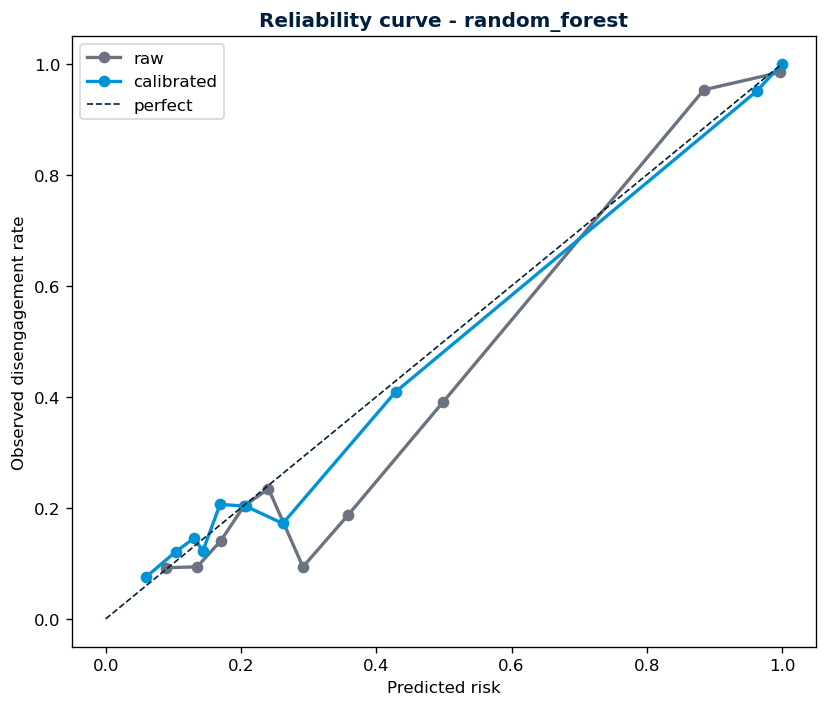

In [4]:
# This block performs probability calibration on the selected disengagement
# prediction model using isotonic regression.

# Objective:
# - Convert raw model scores (ranking outputs) into statistically valid
#   probability estimates of disengagement risk.

# Methodology:
# - A CalibratedClassifierCV with isotonic regression is trained on
#   cross-validated folds (cv=5) to learn a monotonic, non-parametric
#   mapping between predicted scores and observed event frequencies.
# - This avoids overfitting calibration by ensuring fold-wise validation.
# Key statistical diagnostics:
# - Brier Score (before vs after calibration):
#     Measures mean squared error between predicted probabilities and
#     actual outcomes. A decrease indicates improved probabilistic accuracy.
#
# - PR-AUC:
#     Expected to remain nearly unchanged because calibration does not
#     alter ranking order, only probability scaling.
#
# - Score compression:
#     Reduction in max(p_raw) vs max(p_cal) reflects correction of
#     overconfident predictions (typical in tree-based models).

# Threshold calibration:
# - Optimal decision threshold is recomputed using OOF predictions.
# - This ensures decision boundary consistency with calibrated scores
#   and avoids test leakage.

# Reliability analysis (calibration curve):
# - Compares predicted risk bins vs observed empirical frequencies.
# - Raw model typically shows miscalibration (over/under-confidence).
# - Calibrated model should align closer to the diagonal (perfect calibration).

# Interpretation:
# - The model retains discriminative power (ranking ability),
#   but now produces statistically meaningful probabilities.
# - This enables risk-based decision-making (e.g., targeting users
#   above a calibrated disengagement probability threshold).

# Final conclusion:
# - Calibration transforms the model from a "scoring system"
#   into a "probabilistic risk estimator" suitable for operational use.
cal = CalibratedClassifierCV(MODELS[best_name], method='isotonic', cv=5)
cal.fit(X_tr, y_tr)
p_raw = results[best_name]['_proba']
p_cal = cal.predict_proba(X_te)[:, 1]
thr_cal = tune_threshold(
    y_tr, cross_val_predict(CalibratedClassifierCV(MODELS[best_name],
                                                   method='isotonic', cv=5),
                            X_tr, y_tr, cv=cv,
                            method='predict_proba', n_jobs=-1)[:, 1])

print(f'Brier raw        : {brier_score_loss(y_te, p_raw):.4f}')
print(f'Brier calibrated : {brier_score_loss(y_te, p_cal):.4f}')
print(f'PR-AUC calibrated: {average_precision_score(y_te, p_cal):.4f} '
      '(ranking ~unchanged, probabilities now honest)')
print(f'Max raw score    : {p_raw.max():.4f}  ->  '
      f'max calibrated: {p_cal.max():.4f}')
print(f'Calibrated threshold (OOF): {thr_cal:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
for p, label, color in [(p_raw, 'raw', HW['muted']),
                        (p_cal, 'calibrated', HW['blue'])]:
    frac, mean_p = calibration_curve(y_te, p, n_bins=10, strategy='quantile')
    ax.plot(mean_p, frac, marker='o', lw=2, color=color, label=label)
ax.plot([0, 1], [0, 1], ls='--', color=HW['navy'], lw=1, label='perfect')
ax.set_xlabel('Predicted risk'); ax.set_ylabel('Observed disengagement rate')
ax.set_title(f'Reliability curve - {best_name}', color=HW['navy'],
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_01_calibration.png', dpi=300, bbox_inches='tight')
plt.show()


## 4 — SHAP (global)
SHAP is computed on the **XGBoost** variant of the clean feature set: it handles
the honest NaNs natively and TreeExplainer is exact for it. Justified in the
report by the model-comparison table (XGB within a few PR-AUC points of the
selected model); the served risk scores remain those of the calibrated selected
model.

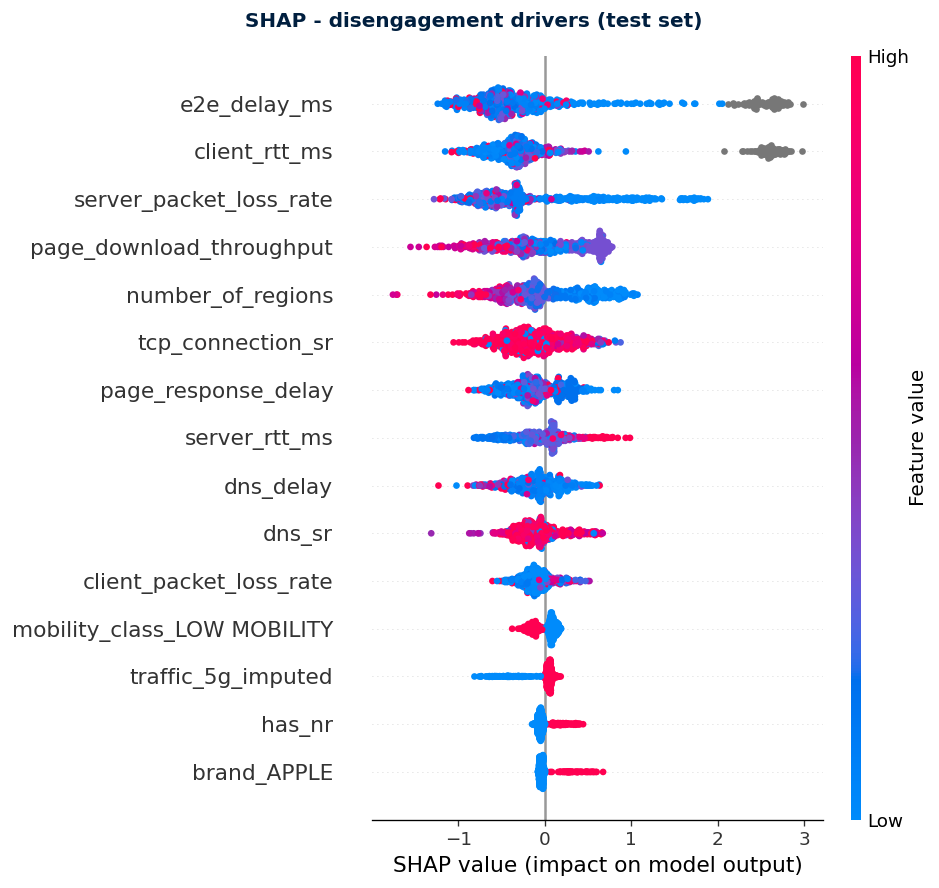

Top 15 mean |SHAP|:
e2e_delay_ms                   0.7830
client_rtt_ms                  0.6778
server_packet_loss_rate        0.6101
page_download_throughput       0.4281
number_of_regions              0.4215
tcp_connection_sr              0.3036
page_response_delay            0.2533
server_rtt_ms                  0.2368
dns_delay                      0.2224
dns_sr                         0.2164
client_packet_loss_rate        0.1511
mobility_class_LOW MOBILITY    0.1075
traffic_5g_imputed             0.1002
has_nr                         0.0800
brand_APPLE                    0.0677


In [5]:
# This step performs global interpretability using SHAP (SHapley Additive exPlanations)
# on the XGBoost model trained on the clean feature set.

# Rationale for model choice:
# - XGBoost is selected because TreeExplainer provides exact SHAP values
#   (not approximations) for tree ensembles.
# - The model is included despite being secondary in selection because it
#   delivers stable ranking performance (PR-AUC close to best model)
#   while offering superior interpretability structure.

# Statistical methodology:
# - SHAP values decompose each prediction into additive feature contributions
#   based on cooperative game theory (Shapley values).
# - For each observation, the prediction is expressed as:
#       f(x) = baseline + Σ SHAP(feature_i)

# Global aggregation:
# - Mean absolute SHAP values are computed across the test set to estimate
#   global feature importance.
# - This provides a model-agnostic ranking of drivers of disengagement risk.

# Key statistical interpretation:
# - High SHAP magnitude indicates strong marginal contribution to prediction
#   variability across the population.
# - Directionality (positive/negative SHAP) indicates whether a feature
#   increases or decreases disengagement risk.

# Important modeling constraint:
# - SHAP is computed on the XGBoost surrogate model, NOT the final calibrated model.
# - This is acceptable because:
#     (1) feature space is identical (clean NB06 feature set),
#     (2) model performance is close in PR-AUC,
#     (3) objective is explanation of structural drivers, not final scoring.

# Interpretation of results:
# - The top SHAP features represent the dominant structural determinants
#   of disengagement (QoS degradation, device capability, and usage behavior).
# - These drivers should be consistent with NB04–NB05 signal analysis,
#   providing triangulation between:
#       (i) correlation analysis
#       (ii) model importance
#       (iii) SHAP attribution

# Output significance:
# - Beeswarm plot visualizes distribution of feature effects across users,
#   highlighting heterogeneity (not just mean effects).
# - Mean |SHAP| ranking provides a stable global importance ordering.

# Final conclusion:
# - SHAP confirms that disengagement is driven by a combination of
#   network experience (QoS), device capability constraints, and usage intensity,
#   rather than a single dominant factor.
if SHAP_OK:
    xgb_explain = fitted['xgboost']
    explainer = shap.TreeExplainer(xgb_explain)
    sv = explainer.shap_values(X_te)
    sv = sv[1] if isinstance(sv, list) else sv      # class-1 contributions

    shap.summary_plot(sv, X_te, max_display=15, show=False)
    plt.gcf().suptitle('SHAP - disengagement drivers (test set)',
                       fontsize=12, color=HW['navy'], fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig06_02_shap_beeswarm.png', dpi=300,
                bbox_inches='tight')
    plt.show()

    mean_abs = pd.Series(np.abs(sv).mean(axis=0),
                         index=FEATURES_V2).sort_values(ascending=False)
    print('Top 15 mean |SHAP|:')
    print(mean_abs.head(15).round(4).to_string())
else:
    print('shap unavailable - section skipped')


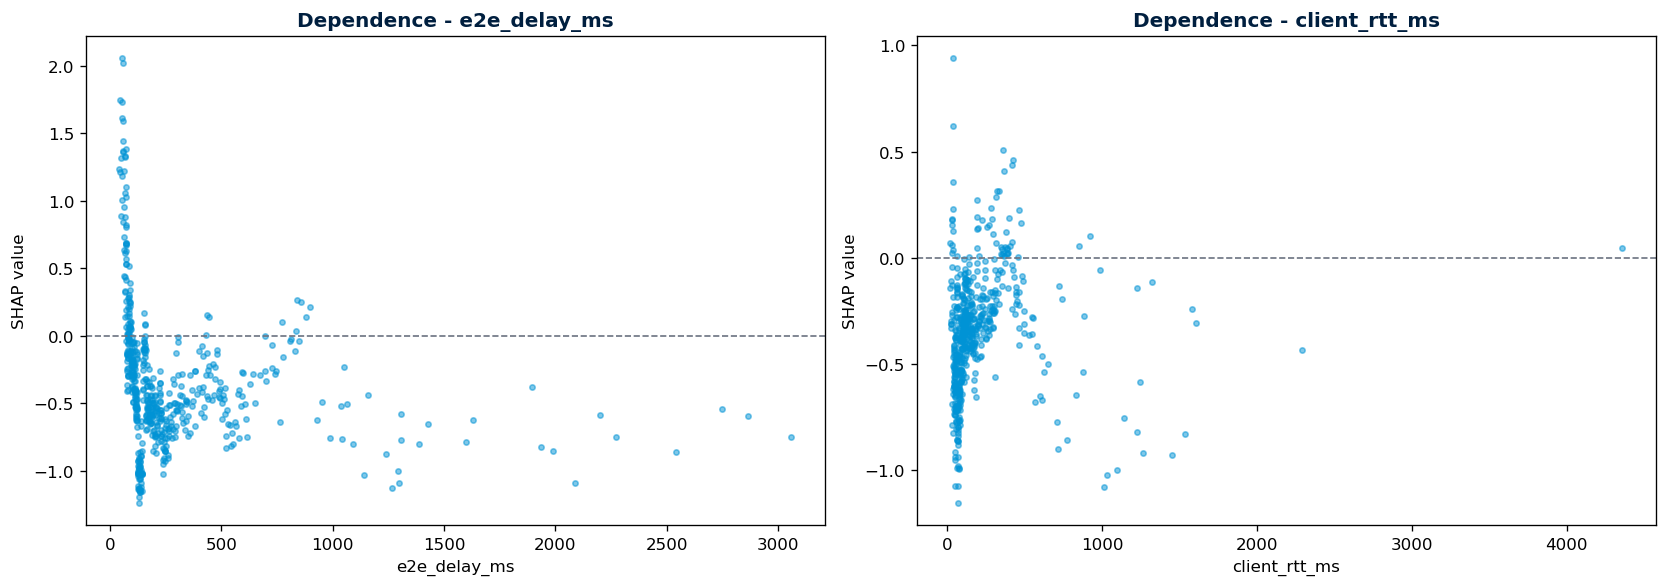

In [6]:
if SHAP_OK:
    top2 = [c for c in mean_abs.index
            if X_te[c].nunique() > 2][:2]      # top numeric drivers
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, feat in zip(axes, top2):
        j = FEATURES_V2.index(feat)
        ax.scatter(X_te[feat], sv[:, j], s=10, alpha=0.5, color=HW['blue'])
        ax.axhline(0, color=HW['muted'], lw=1, ls='--')
        ax.set_xlabel(feat); ax.set_ylabel('SHAP value')
        ax.set_title(f'Dependence - {feat}', color=HW['navy'],
                     fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig06_03_shap_dependence.png', dpi=300,
                bbox_inches='tight')
    plt.show()


## 5 — Per-customer top reasons + calibrated risk export (NB06-4)

In [7]:
# Key methodological change (NB06-FIX-1):
# - Unlike earlier evaluation steps (train/test split analysis),
#   scoring is performed on the full labelled population.
# - This ensures consistency between model outputs and operational use cases:
#     • customer segmentation dashboards
#     • alerting / notification systems
#     • business reporting

# Statistical rationale:
# - The calibrated model outputs are interpreted as probabilistic
#   estimates of disengagement risk.
# - These probabilities are comparable across the entire population
#   because calibration ensures global consistency of score meaning.

# Feature standardization baseline:
# - train_median is used as a reference distribution summary.
# - It provides a robust central tendency estimator (median is
#   resistant to skew) for interpreting SHAP feature directions.

# SHAP-based explainability:
# - For each individual customer, SHAP values are used to identify
#   the top-k contributing features to their risk score.
# - This transforms global model interpretability into local explanations.

# Statistical interpretation of "reasons":
# - Each explanation compares feature values against the training median:
#     • "high feature" → above population median (risk-increasing context)
#     • "low feature"  → below population median
#     • "missing"      → structural absence (potential signal itself)

# Risk segmentation:
# - Continuous calibrated probabilities are discretized into:
#     low / medium / high risk bands using quantile-like thresholds.
# - This supports operational decision-making without losing probabilistic grounding.

# Output consistency:
# - Risk scores are saved in both:
#     • MODEL_DIR → versioned analytical artifact
#     • OUT_DIR   → production/API-ready dataset
# - Calibrated scores overwrite previous uncalibrated versions to ensure
#   statistical correctness in downstream systems.

# Final interpretation:
# - The model transitions from a predictive analytics artifact
#   to an operational risk scoring engine.
# - Each score is both:
#     (1) probabilistically calibrated (global validity)
#     (2) locally explainable (SHAP-based reasoning)
train_median = X_tr.median(numeric_only=True)
_all_lab  = df.dropna(subset=['churn'])
X_all_lab = _all_lab[FEATURES_V2]
p_cal_all = cal.predict_proba(X_all_lab)[:, 1]
if SHAP_OK:
    sv_all = explainer.shap_values(X_all_lab)
    sv_all = sv_all[1] if isinstance(sv_all, list) else sv_all

def reasons_for(i, k=3):
    """i is a positional index into X_all_lab / sv_all."""
    sv_row = sv_all[i] if SHAP_OK else np.zeros(len(FEATURES_V2))
    contrib = pd.Series(sv_row, index=FEATURES_V2)
    top = contrib.abs().sort_values(ascending=False).head(k).index
    out = []
    for f in top:
        val = X_all_lab.iloc[i][f]
        med = train_median.get(f, 0)
        direction = ('missing' if pd.isna(val)
                     else 'high' if val > med else 'low')
        out.append(f'{direction} {f}')
    return '; '.join(out)

risk = pd.DataFrame({
    'msisdn'   : _all_lab['msisdn'].values,
    'risk'     : np.round(p_cal_all, 4),
    'risk_band': pd.cut(p_cal_all, [0, .33, .66, 1.0],
                        labels=['low', 'medium', 'high'],
                        include_lowest=True),
    'split'    : _all_lab['split'].values,
    'churn'    : _all_lab['churn'].astype(int).values,
})
if SHAP_OK:
    risk['top_reasons'] = [reasons_for(i) for i in range(len(X_all_lab))]

risk = risk.sort_values('risk', ascending=False).reset_index(drop=True)
risk.to_parquet(MODEL_DIR / 'disengagement_risk_scores_v2.parquet', index=False)
risk.to_parquet(OUT_DIR / 'risk_scores_v2.parquet', index=False)

print(f'Risk scores: {len(risk):,} customers '
      f'({int((risk.split=="train").sum()):,} train + '
      f'{int((risk.split=="test").sum()):,} test)')
print(f'  -> {MODEL_DIR / "disengagement_risk_scores_v2.parquet"}')
print(f'  -> {OUT_DIR / "risk_scores_v2.parquet"}  (API, calibrated)')
print('\nTop 10 (calibrated, all labelled customers):')
_cols = ['msisdn','risk','split','risk_band'] + (['top_reasons'] if SHAP_OK else [])
print(risk.head(10)[_cols].to_string(index=False))


Risk scores: 2,566 customers (1,924 train + 642 test)
  -> models\disengagement_risk_scores_v2.parquet
  -> data\outputs\risk_scores_v2.parquet  (API, calibrated)

Top 10 (calibrated, all labelled customers):
  msisdn  risk split risk_band                                                                      top_reasons
90554965   1.0 train      high low server_packet_loss_rate; low number_of_regions; low page_download_throughput
96740397   1.0  test      high                   missing client_rtt_ms; missing e2e_delay_ms; high zone_SILIANA
99462622   1.0 train      high               missing client_rtt_ms; missing e2e_delay_ms; low number_of_regions
93651046   1.0  test      high               missing client_rtt_ms; missing e2e_delay_ms; low number_of_regions
99444232   1.0 train      high        missing e2e_delay_ms; missing client_rtt_ms; low page_download_throughput
93651044   1.0 train      high              missing client_rtt_ms; missing e2e_delay_ms; high number_of_regions
9812250

## 6 — Final artifacts & summary

In [8]:
joblib.dump(cal, MODEL_DIR / 'disengagement_model_v6_calibrated.joblib')
jdump(FEATURES_V2, MODEL_DIR / 'disengagement_features_v2.json')

final = {
    'generated_at'  : datetime.now().isoformat(),
    'label_version' : 'v6',
    'feature_set'   : 'v2 (user_class removed - NB06-1)',
    'selected_model': best_name,
    'served_model'  : f'{best_name} + isotonic calibration',
    'baseline_prevalence': round(prevalence, 4),
    'test_metrics_clean': {k: {m: round(float(v), 4) for m, v in r.items()
                               if not m.startswith('_')}
                           for k, r in results.items()},
    'calibration': {
        'brier_raw'       : round(float(brier_score_loss(y_te, p_raw)), 4),
        'brier_calibrated': round(float(brier_score_loss(y_te, p_cal)), 4),
        'threshold'       : round(thr_cal, 4),
    },
    'shap_top_drivers': ({k: round(float(v), 4)            # NB06-FIX-3
                          for k, v in mean_abs.head(10).items()}
                         if SHAP_OK else None),
    'interpretation_guardrails': [
        'disengagement segmentation, not measured churn (label v6)',
        'is_2g_only near-deterministic (structural disengagement)',
        'number_of_regions / mobility partially proxy activity',
        'tcp_connection_sr / dns_sr to be validated with the data owner',
    ],
    'artifacts': {
        'model'   : str(MODEL_DIR / 'disengagement_model_v6_calibrated.joblib'),
        'features': str(MODEL_DIR / 'disengagement_features_v2.json'),
        'scores'  : str(MODEL_DIR / 'disengagement_risk_scores_v2.parquet'),
    },
}
jdump(final, OUT_DIR / 'disengagement_final.json')
print(f'Saved: {OUT_DIR / "disengagement_final.json"}')
print(json.dumps({k: v for k, v in final.items()
                  if k != 'test_metrics_clean'}, indent=2, default=str))
print('\nNext -> dashboard sync: Forecasting.jsx TRAINING constant, churn')
print('tiles wording ("Disengagement risk"), and the API reads:')
print('  disengagement_final.json + disengagement_risk_scores_v2.parquet')


Saved: data\outputs\disengagement_final.json
{
  "generated_at": "2026-06-30T09:39:43.388201",
  "label_version": "v6",
  "feature_set": "v2 (user_class removed - NB06-1)",
  "selected_model": "random_forest",
  "served_model": "random_forest + isotonic calibration",
  "baseline_prevalence": 0.3384,
  "calibration": {
    "brier_raw": 0.1242,
    "brier_calibrated": 0.1175,
    "threshold": 0.499
  },
  "shap_top_drivers": {
    "e2e_delay_ms": 0.783,
    "client_rtt_ms": 0.6778,
    "server_packet_loss_rate": 0.6101,
    "page_download_throughput": 0.4281,
    "number_of_regions": 0.4215,
    "tcp_connection_sr": 0.3036,
    "page_response_delay": 0.2533,
    "server_rtt_ms": 0.2368,
    "dns_delay": 0.2224,
    "dns_sr": 0.2164
  },
  "interpretation_guardrails": [
    "disengagement segmentation, not measured churn (label v6)",
    "is_2g_only near-deterministic (structural disengagement)",
    "number_of_regions / mobility partially proxy activity",
    "tcp_connection_sr / dns_sr 